# LoomAnalysisCR - multi-experiment loom analysis

This notebook extends the legacy `CLfull...` loom analyses to the dynamically selected 2026 shoaling-selection experiments. Each recording is reduced to experiment-level values before experiments are combined, so experiments remain equally weighted replicates.

## Settings

In [1]:
from pathlib import Path
import os

repo_candidate = Path.cwd()
if repo_candidate.name == 'Analyses':
    repo_candidate = repo_candidate.parent
CODE_DIR = Path(os.environ.get('JLSOCIALBEHAVIOR_CODE_DIR', repo_candidate)).resolve()
os.chdir(CODE_DIR)

META_FOLDER = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/')
META_FILE = 'MetaData_CR.xlsx'
PROCESSING_ROOT_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/')
PROCESSING_DIR = PROCESSING_ROOT_DIR / 'LoomAnalysisCR_temp_processing'

# Cohort controls mirror ShoalingNeighborhoodMaps_2026.ipynb.
INCLUDE_YEARS = [2026]
INCLUDE_LINES = None
INCLUDE_GENOTYPES = None
INCLUDE_LINESETS = None
INCLUDE_EXPERIMENT_FOLDERS = None
EXCLUDE_EXPERIMENT_FOLDERS = []
EXPECTED_EXPERIMENT_COUNT = 8

# Raw extraction and cache controls inherited from the original loom notebook.
FORCE_REPROCESS_RAW_DATA = False
LEGACY_ONSET_IN_BLOCK = 150
PRE_FRAMES = 50
POST_FRAMES = 99
BASELINE_FRAMES = (100, 140)
RESPONSE_FRAMES = (149, 180)
VELOCITY_FRAME_START = 0
VELOCITY_FRAME_END = 300
VELOCITY_STEP_FRAMES = 30
FPS = 30
UNITS_PER_MM = 4.0
MAX_VELOCITY_WINDOW_FRAMES = 120

print('Using repository:', CODE_DIR)
print('Using metadata:', META_FOLDER / META_FILE)
print('Using loom cache:', PROCESSING_DIR)

Using repository: C:\Users\crodri19\larschpostdoc_analyses\selection_shoaling\jlsocialbehavior
Using metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\MetaData_CR.xlsx
Using loom cache: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\LoomAnalysisCR_temp_processing


## Imports and plotting utilities

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import functions.joh_loom_helpers as loom

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)

POINT_MODES = {'experiments', 'condition_trial_average'}
SIDE_COLORS = {'L': '#7b4ab8', 'R': '#cf5a33'}

def validate_point_mode(mode):
    if mode not in POINT_MODES:
        raise ValueError(f'Point mode must be one of {sorted(POINT_MODES)}; got {mode!r}.')

def deterministic_jitter(n, width=0.10):
    return np.linspace(-width, width, n) if n > 1 else np.zeros(n)

def pearson_title(frame, x_column, y_column, title):
    finite = frame[[x_column, y_column]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(finite) < 3:
        return title + '\nPearson correlation unavailable (fewer than 3 points)'
    try:
        from scipy.stats import pearsonr
        r_value, p_value = pearsonr(finite[x_column], finite[y_column])
        return title + f'\nPearson r = {r_value:.3f}, p = {p_value:.3g}'
    except ImportError:
        r_value = finite[x_column].corr(finite[y_column])
        return title + f'\nPearson r = {r_value:.3f}, p unavailable'

## Select the 2026 shoaling-selection experiments

Selection uses `AllExp` and `AllAn` from the shared metadata workbook. The year and optional line/genotype/lineSet/folder filters have the same intersection semantics as the neighborhood-map notebook.

In [3]:
experiments, missing_inputs = loom.select_loom_experiments(
    META_FOLDER / META_FILE,
    include_years=INCLUDE_YEARS,
    include_lines=INCLUDE_LINES,
    include_genotypes=INCLUDE_GENOTYPES,
    include_line_sets=INCLUDE_LINESETS,
    include_folders=INCLUDE_EXPERIMENT_FOLDERS,
    exclude_folders=EXCLUDE_EXPERIMENT_FOLDERS,
)

if experiments.empty:
    raise ValueError('No usable experiments passed the current metadata and raw-file filters.')
if len(experiments) != EXPECTED_EXPERIMENT_COUNT:
    print(
        f'WARNING: expected {EXPECTED_EXPERIMENT_COUNT} experiments but selected {len(experiments)}. '
        'Review the displayed cohort before continuing.'
    )
if not missing_inputs.empty:
    print(f'WARNING: {len(missing_inputs)} selected metadata rows have no PositionTxt input:')
    display(missing_inputs)

display(experiments[[
    'experiment_index', 'experiment', 'exp_year', 'n_animals',
    'lines', 'genotypes', 'line_sets', 'txt_path'
]])

,experiment_index,experiment,exp_year,n_animals,lines,genotypes,line_sets,txt_path
0,0,20260213_01_35Animals_s2_TLSel1F10.1,2026,35,[Sel1_10.1],"[hi, lo]",[Sel1_10.1_13-02-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
1,1,20260303_01_35Animals_s1_TLSel1F10.1,2026,35,[Sel1_10.1],"[esc_lo, hi, lo]",[Sel1_10.1_03-03-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
2,2,20260305_02_35Animals_s2_TLSel1GC8,2026,35,[Sel1_GC8],"[hi, lo]",[Sel1_GC8_05-03-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
3,3,20260313_01_35Animals_s2_TLSel1F10.1,2026,35,[Sel1_10.1],"[hi, lo]",[Sel1_10.1_13-03-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
4,4,20260330_01_35Animals_s2_TLSel3F8.1,2026,35,[Sel3_8.1],"[esc_hi, hi, lo]",[Sel3_8.1_30-03-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
5,5,20260407_01_35Animals_s2_TLSel1F10.1,2026,35,[Sel1_10.1],"[esc_hi, esc_lo, hi, lo]",[Sel1_10.1_07-04-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
6,6,20260507_01_35Animals_s1_TLSel1GC8,2026,35,[Sel1_GC8],"[hi, lo]",[Sel1_GC8_07-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...
7,7,20260507_02_35Animals_s2_TLSel1GC8,2026,35,[Sel1_GC8],"[hi, lo]",[Sel1_GC8_07-05-2026],\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...


## Extract or load compact loom tables

Raw recordings are processed one at a time. Cached experiment-level tables are reused only when their settings sidecar and raw-file signature still match.

In [4]:
loom_tables = loom.collect_or_load_loom_analysis_data(
    experiments,
    PROCESSING_DIR,
    force_reprocess=FORCE_REPROCESS_RAW_DATA,
    onset_in_block=LEGACY_ONSET_IN_BLOCK,
    pre_frames=PRE_FRAMES,
    post_frames=POST_FRAMES,
    baseline_frames=BASELINE_FRAMES,
    response_frames=RESPONSE_FRAMES,
    velocity_frame_start=VELOCITY_FRAME_START,
    velocity_frame_end=VELOCITY_FRAME_END,
    velocity_step_frames=VELOCITY_STEP_FRAMES,
    fps=FPS,
    units_per_mm=UNITS_PER_MM,
    max_velocity_window_frames=MAX_VELOCITY_WINDOW_FRAMES,
)

center_traces = loom_tables['center_traces']
response_metrics = loom_tables['response_metrics']
trial_velocity = loom_tables['trial_velocity']
trial_max_velocity = loom_tables['trial_max_velocity']

display(pd.DataFrame({
    'table': list(loom_tables),
    'rows': [len(loom_tables[name]) for name in loom_tables],
    'experiments': [loom_tables[name]['experiment'].nunique() for name in loom_tables],
}))

Loading loom cache 1/8: 20260213_01_35Animals_s2_TLSel1F10.1
Loading loom cache 2/8: 20260303_01_35Animals_s1_TLSel1F10.1
Loading loom cache 3/8: 20260305_02_35Animals_s2_TLSel1GC8
Loading loom cache 4/8: 20260313_01_35Animals_s2_TLSel1F10.1
Loading loom cache 5/8: 20260330_01_35Animals_s2_TLSel3F8.1
Loading loom cache 6/8: 20260407_01_35Animals_s2_TLSel1F10.1
Loading loom cache 7/8: 20260507_01_35Animals_s1_TLSel1GC8
Loading loom cache 8/8: 20260507_02_35Animals_s2_TLSel1GC8


,table,rows,experiments
0,center_traces,19200,8
1,response_metrics,192,8
2,trial_velocity,3200,8
3,trial_max_velocity,320,8


## 1. Legacy center-distance traces

Repeated trials and animals were averaged within each experiment during extraction. Lines and SEM bands below therefore summarize equally weighted experiment traces.

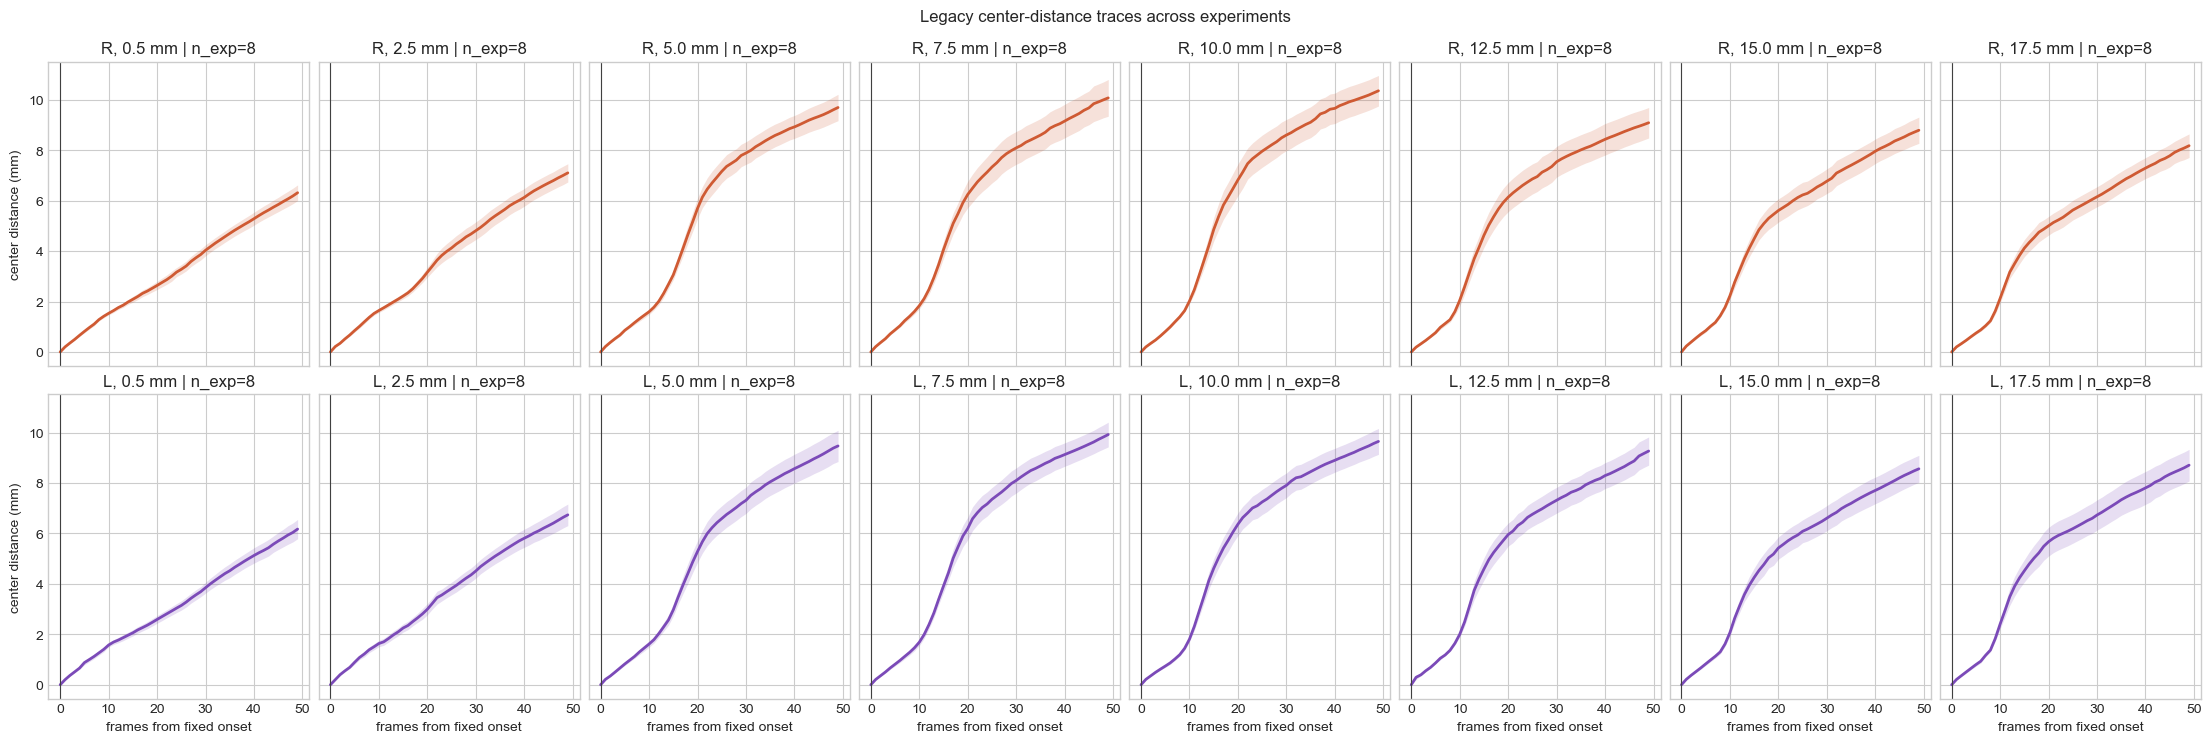

,loom_max_size,side,relative_frame,center_dist_mm_mean,center_dist_mm_sem,n_experiments
0,1,L,0,0.000000,0.000000,8
1,1,L,1,0.200817,0.008174,8
2,1,L,2,0.368205,0.027057,8
3,1,L,3,0.514071,0.037486,8
4,1,L,4,0.661757,0.048830,8


In [5]:
CENTER_TRACE_FRAME_RANGE = (0, 49)

center_window = center_traces.loc[
    center_traces['relative_frame'].between(*CENTER_TRACE_FRAME_RANGE)
].copy()
center_stats = loom.summarize_across_experiments(
    center_window,
    ['loom_max_size', 'side', 'relative_frame'],
    ['center_dist_mm'],
)
all_sizes = sorted(center_stats['loom_max_size'].unique())
fig, axes = plt.subplots(2, len(all_sizes), figsize=(22, 7), sharex=True, sharey=True, constrained_layout=True)
if len(all_sizes) == 1:
    axes = np.asarray(axes).reshape(2, 1)

for row_index, side in enumerate(['R', 'L']):
    for column_index, size in enumerate(all_sizes):
        ax = axes[row_index, column_index]
        trace = center_stats.loc[
            center_stats['side'].eq(side) & center_stats['loom_max_size'].eq(size)
        ].sort_values('relative_frame')
        x = trace['relative_frame'].to_numpy(dtype=float)
        mean = trace['center_dist_mm_mean'].to_numpy(dtype=float)
        sem = trace['center_dist_mm_sem'].to_numpy(dtype=float)
        ax.plot(x, mean, color=SIDE_COLORS[side], lw=2)
        ax.fill_between(x, mean - sem, mean + sem, color=SIDE_COLORS[side], alpha=0.18, lw=0)
        ax.axvline(0, color='0.25', lw=0.8)
        n_experiments = int(trace['n_experiments'].max()) if not trace.empty else 0
        ax.set_title(f'{side}, {size / 2:.1f} mm | n_exp={n_experiments}')
        if column_index == 0:
            ax.set_ylabel('center distance (mm)')
        if row_index == 1:
            ax.set_xlabel('frames from fixed onset')
fig.suptitle('Legacy center-distance traces across experiments', y=1.04)
plt.show()
display(center_stats.head())

## 2. Legacy baseline/response metrics

The source hierarchy is preserved within each experiment: repeated trials are averaged per animal, then animals are averaged. Change the switch in the next cell to show all experiment replicates or only cross-experiment condition averages.

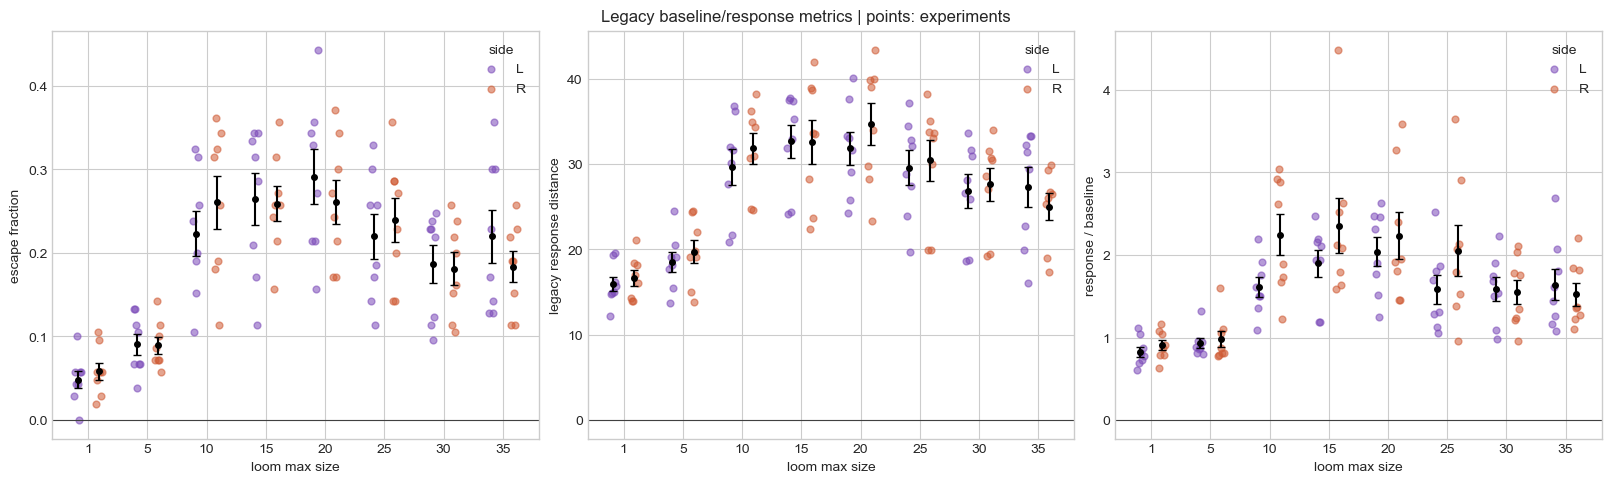

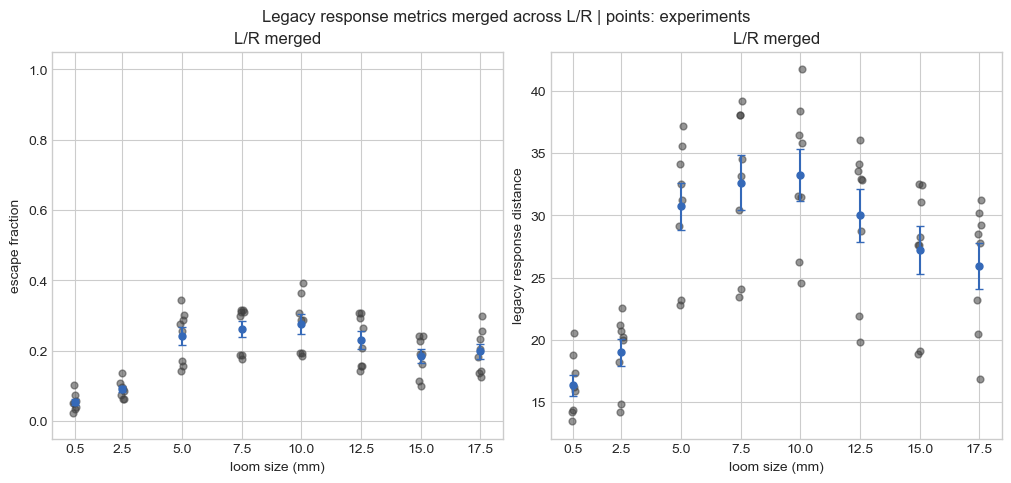

,loom_max_size,side,escape_mean,response_dist_mean,response_over_baseline_mean,escape_sem,response_dist_sem,response_over_baseline_sem,n_experiments
0,1,L,0.048214,15.947804,0.830112,0.010079,0.863706,0.060794,8
1,1,R,0.058333,16.637639,0.909777,0.010408,0.904882,0.061543,8
2,5,L,0.090476,18.517034,0.931024,0.012599,1.144110,0.059010,8
3,5,R,0.089286,19.727079,0.979119,0.010011,1.377624,0.099330,8
4,10,L,0.222619,29.617373,1.617402,0.026873,2.101197,0.120738,8
5,10,R,0.260714,31.827906,2.246432,0.031788,1.793952,0.245393,8
6,15,L,0.264286,32.644526,1.898262,0.031109,1.977056,0.165668,8
7,15,R,0.258929,32.609076,2.355804,0.021333,2.571190,0.332609,8
8,20,L,0.291071,31.858392,2.038793,0.033168,1.921842,0.178426,8
9,20,R,0.260714,34.699327,2.231304,0.026418,2.477357,0.285006,8


In [6]:
BASELINE_POINT_MODE = 'experiments'  # 'experiments' or 'condition_trial_average'
validate_point_mode(BASELINE_POINT_MODE)

side_response = response_metrics.loc[response_metrics['aggregation'].eq('side_resolved')].copy()
side_stats = loom.summarize_across_experiments(
    side_response, ['loom_max_size', 'side'],
    ['escape', 'response_dist', 'response_over_baseline'],
)
sizes = sorted(side_response['loom_max_size'].unique())
x_base = np.arange(len(sizes), dtype=float)
offsets = {'L': -0.18, 'R': 0.18}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for ax, metric, ylabel in [
    (axes[0], 'escape', 'escape fraction'),
    (axes[1], 'response_dist', 'legacy response distance'),
    (axes[2], 'response_over_baseline', 'response / baseline'),
]:
    for side in ['L', 'R']:
        for size_index, size in enumerate(sizes):
            position = x_base[size_index] + offsets[side]
            raw = side_response.loc[side_response['side'].eq(side) & side_response['loom_max_size'].eq(size)]
            stats = side_stats.loc[side_stats['side'].eq(side) & side_stats['loom_max_size'].eq(size)].iloc[0]
            if BASELINE_POINT_MODE == 'experiments':
                values = raw[metric].dropna().to_numpy(dtype=float)
                ax.scatter(position + deterministic_jitter(len(values), 0.055), values, color=SIDE_COLORS[side], alpha=0.55, s=24, label=side if size_index == 0 else None)
            else:
                ax.scatter(position, stats[f'{metric}_mean'], color=SIDE_COLORS[side], s=42, zorder=3, label=side if size_index == 0 else None)
            ax.errorbar(position, stats[f'{metric}_mean'], yerr=stats[f'{metric}_sem'], color='black', marker='o', capsize=3, ms=4, zorder=4)
    ax.axhline(0, color='0.25', lw=0.8)
    ax.set_xticks(x_base)
    ax.set_xticklabels([str(size) for size in sizes])
    ax.set_xlabel('loom max size')
    ax.set_ylabel(ylabel)
    ax.legend(title='side')
fig.suptitle(f'Legacy baseline/response metrics | points: {BASELINE_POINT_MODE}', y=1.04)
plt.show()

merged_response = response_metrics.loc[response_metrics['aggregation'].eq('lr_merged')].copy()
merged_stats = loom.summarize_across_experiments(
    merged_response, ['loom_max_size'], ['escape', 'response_dist']
)
size_x = np.asarray(sizes, dtype=float) / 2.0
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, metric, ylabel in [
    (axes[0], 'escape', 'escape fraction'),
    (axes[1], 'response_dist', 'legacy response distance'),
]:
    for size_index, size in enumerate(sizes):
        raw = merged_response.loc[merged_response['loom_max_size'].eq(size)]
        stats = merged_stats.loc[merged_stats['loom_max_size'].eq(size)].iloc[0]
        if BASELINE_POINT_MODE == 'experiments':
            values = raw[metric].dropna().to_numpy(dtype=float)
            ax.scatter(size_x[size_index] + deterministic_jitter(len(values), 0.08), values, color='0.25', alpha=0.55, s=24)
        else:
            ax.scatter(size_x[size_index], stats[f'{metric}_mean'], color='#3569b8', s=42, zorder=3)
        ax.errorbar(size_x[size_index], stats[f'{metric}_mean'], yerr=stats[f'{metric}_sem'], color='#3569b8', marker='o', capsize=3, ms=5, zorder=4)
    ax.set_xlabel('loom size (mm)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(size_x)
    ax.set_title('L/R merged')
axes[0].set_ylim(-0.05, 1.05)
fig.suptitle(f'Legacy response metrics merged across L/R | points: {BASELINE_POINT_MODE}', y=1.04)
plt.show()
display(side_stats)

## 3. Trial-level mean velocity across animals

Animals are averaged within each experiment and trial. Matching one-based condition trials are then averaged across experiments, with SEM bands showing between-experiment uncertainty.

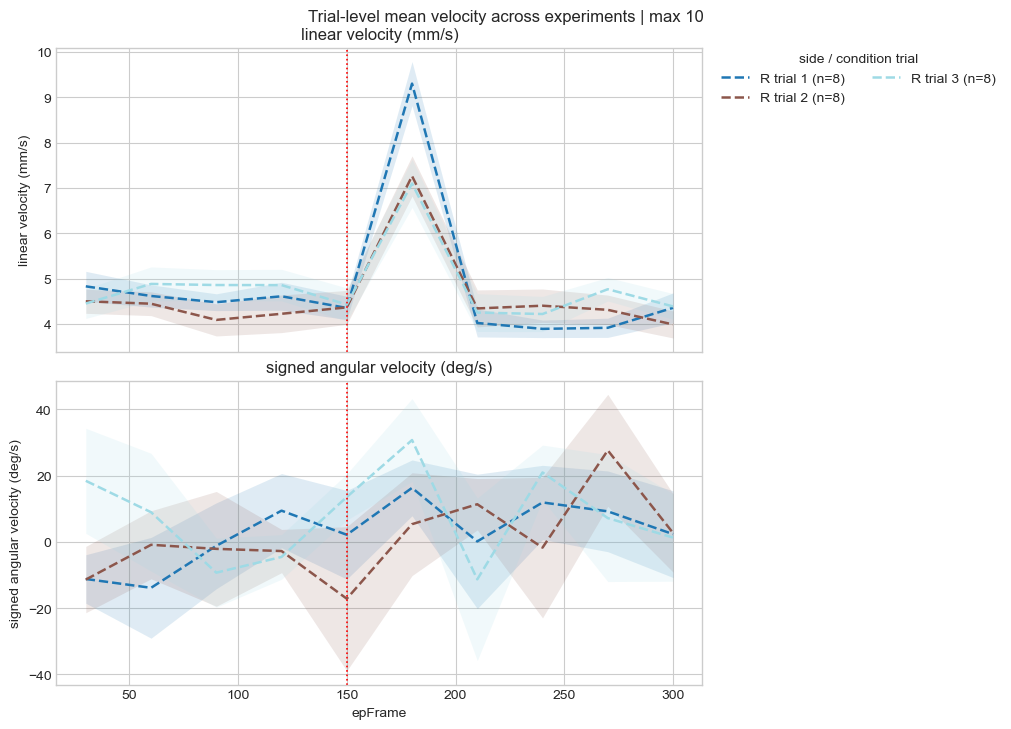

,loom_max_size,side,condition_trial,epFrame,linear_velocity_mm_s_mean,signed_angular_velocity_deg_s_mean,linear_velocity_mm_s_sem,signed_angular_velocity_deg_s_sem,n_experiments
0,10,R,1,30,4.828131,-11.179891,0.330662,7.320402,8
1,10,R,1,60,4.615354,-13.847123,0.245383,15.201649,8
2,10,R,1,90,4.477877,-1.166951,0.185715,12.958467,8
3,10,R,1,120,4.608619,9.433506,0.309013,11.196178,8
4,10,R,1,150,4.351529,2.159810,0.256861,13.376115,8


In [7]:
TRIAL_AVG_VELOCITY_LOOM_MAX_SIZE = 10
TRIAL_AVG_VELOCITY_SIDES = ('R',)  # choose ('L',), ('R',), or ('L', 'R')
TRIAL_AVG_VELOCITY_METRICS = {
    'linear_velocity_mm_s': 'linear velocity (mm/s)',
    'signed_angular_velocity_deg_s': 'signed angular velocity (deg/s)',
}

selected_velocity = trial_velocity.loc[
    trial_velocity['loom_max_size'].eq(TRIAL_AVG_VELOCITY_LOOM_MAX_SIZE)
    & trial_velocity['side'].isin(TRIAL_AVG_VELOCITY_SIDES)
].copy()
if selected_velocity.empty:
    raise ValueError('No trial velocity rows match the selected loom size and sides.')
velocity_stats = loom.summarize_across_experiments(
    selected_velocity,
    ['loom_max_size', 'side', 'condition_trial', 'epFrame'],
    list(TRIAL_AVG_VELOCITY_METRICS),
)
line_keys = velocity_stats[['side', 'condition_trial']].drop_duplicates().sort_values(['side', 'condition_trial']).reset_index(drop=True)
colors = plt.cm.tab20(np.linspace(0.02, 0.98, len(line_keys)))
linestyles = {'L': '-', 'R': '--'}
fig, axes = plt.subplots(len(TRIAL_AVG_VELOCITY_METRICS), 1, figsize=(10, 7), sharex=True, constrained_layout=True)
if len(TRIAL_AVG_VELOCITY_METRICS) == 1:
    axes = [axes]
for ax, (metric, ylabel) in zip(axes, TRIAL_AVG_VELOCITY_METRICS.items()):
    for line_index, line_meta in line_keys.iterrows():
        side = line_meta['side']
        condition_trial = int(line_meta['condition_trial'])
        trace = velocity_stats.loc[
            velocity_stats['side'].eq(side) & velocity_stats['condition_trial'].eq(condition_trial)
        ].sort_values('epFrame')
        x = trace['epFrame'].to_numpy(dtype=float)
        mean = trace[f'{metric}_mean'].to_numpy(dtype=float)
        sem = trace[f'{metric}_sem'].to_numpy(dtype=float)
        n_experiments = int(trace['n_experiments'].max())
        ax.plot(x, mean, color=colors[line_index], linestyle=linestyles.get(side, '-'), lw=1.8, label=f'{side} trial {condition_trial} (n={n_experiments})')
        ax.fill_between(x, mean - sem, mean + sem, color=colors[line_index], alpha=0.14, lw=0)
    ax.axvline(LEGACY_ONSET_IN_BLOCK, color='red', linestyle=':', lw=1.2)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
axes[-1].set_xlabel('epFrame')
axes[0].legend(title='side / condition trial', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=2)
fig.suptitle(f'Trial-level mean velocity across experiments | max {TRIAL_AVG_VELOCITY_LOOM_MAX_SIZE}', y=1.02)
plt.show()
display(velocity_stats.head())

## 4. Trial max post-loom velocity vs time since experiment start

Each native point is one experiment×trial value: the median across fish of each fish's maximum speed during the post-loom window. The alternative mode averages matching size/side/condition trials across experiments.

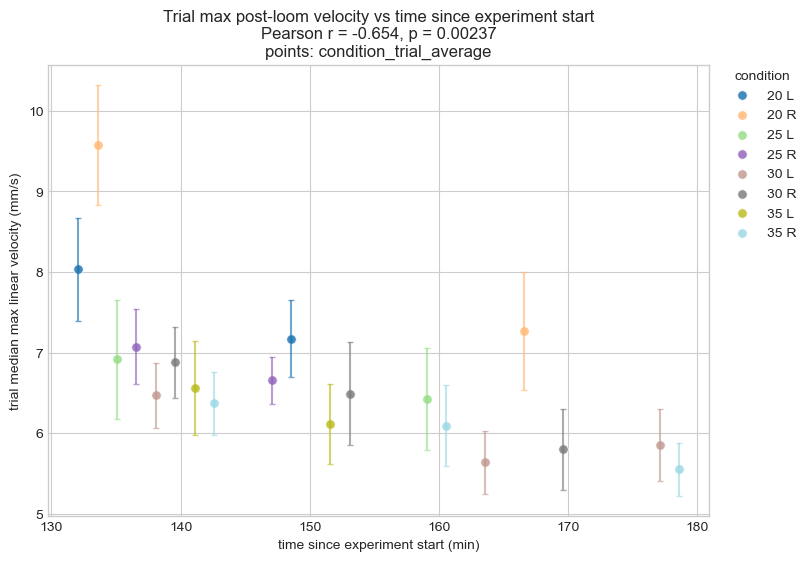

,loom_max_size,side,condition_trial,plot_x,plot_y,plot_x_sem,plot_y_sem,n_experiments,condition
0,20,L,1,132.083333,8.030951,0.0,0.644417,8,20 L
1,20,L,2,148.583333,7.172174,0.0,0.479033,8,20 L
2,20,R,1,133.583333,9.573075,0.0,0.743733,8,20 R
3,20,R,2,166.583333,7.272013,0.0,0.729807,8,20 R
4,25,L,1,135.083333,6.916637,0.0,0.739263,8,25 L
5,25,L,2,159.083333,6.423397,0.0,0.631676,8,25 L
6,25,R,1,136.583333,7.072623,0.0,0.464368,8,25 R
7,25,R,2,147.083333,6.655475,0.0,0.287937,8,25 R
8,30,L,1,138.083333,6.469829,0.0,0.403377,8,30 L
9,30,L,2,163.583333,5.638564,0.0,0.390052,8,30 L


In [8]:
TIME_POINT_MODE = 'condition_trial_average'  # 'experiments' or 'condition_trial_average'
MAX_LOOM_SIZE_EXCLUDE_THRESHOLD = 15
validate_point_mode(TIME_POINT_MODE)

time_source = trial_max_velocity.loc[
    trial_max_velocity['loom_max_size'].gt(MAX_LOOM_SIZE_EXCLUDE_THRESHOLD)
].copy()
value_column = 'trial_median_max_linear_velocity_mm_s'
if TIME_POINT_MODE == 'experiments':
    time_points = time_source.copy()
    time_points['plot_x'] = time_points['time_since_experiment_start_min']
    time_points['plot_y'] = time_points[value_column]
    time_points['plot_x_sem'] = np.nan
    time_points['plot_y_sem'] = np.nan
    time_points['n_experiments'] = 1
else:
    time_points = loom.summarize_across_experiments(
        time_source,
        ['loom_max_size', 'side', 'condition_trial'],
        ['time_since_experiment_start_min', value_column],
    ).rename(columns={
        'time_since_experiment_start_min_mean': 'plot_x',
        'time_since_experiment_start_min_sem': 'plot_x_sem',
        f'{value_column}_mean': 'plot_y',
        f'{value_column}_sem': 'plot_y_sem',
    })
time_points['condition'] = time_points['loom_max_size'].astype(int).astype(str) + ' ' + time_points['side'].astype(str)
conditions = time_points[['loom_max_size', 'side', 'condition']].drop_duplicates().sort_values(['loom_max_size', 'side'])
condition_colors = dict(zip(conditions['condition'], plt.cm.tab20(np.linspace(0.02, 0.98, len(conditions)))))
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
for condition in conditions['condition']:
    subset = time_points.loc[time_points['condition'].eq(condition)]
    ax.scatter(subset['plot_x'], subset['plot_y'], color=condition_colors[condition], s=48, alpha=0.85, edgecolor='white', linewidth=0.7, label=condition)
    if TIME_POINT_MODE == 'condition_trial_average':
        ax.errorbar(subset['plot_x'], subset['plot_y'], xerr=subset['plot_x_sem'], yerr=subset['plot_y_sem'], fmt='none', ecolor=condition_colors[condition], alpha=0.65, capsize=2)
title = pearson_title(time_points, 'plot_x', 'plot_y', 'Trial max post-loom velocity vs time since experiment start')
ax.set_xlabel('time since experiment start (min)')
ax.set_ylabel('trial median max linear velocity (mm/s)')
ax.set_title(title + f'\npoints: {TIME_POINT_MODE}')
ax.legend(title='condition', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()
display(time_points.sort_values(['loom_max_size', 'side', 'condition_trial']).head(30))

## 5. Trial max post-loom velocity by loom side

The first layout resolves loom size within side; the second pools sizes within side. The switch controls whether boxes and dots use experiment×trial values or cross-experiment aligned-trial averages.

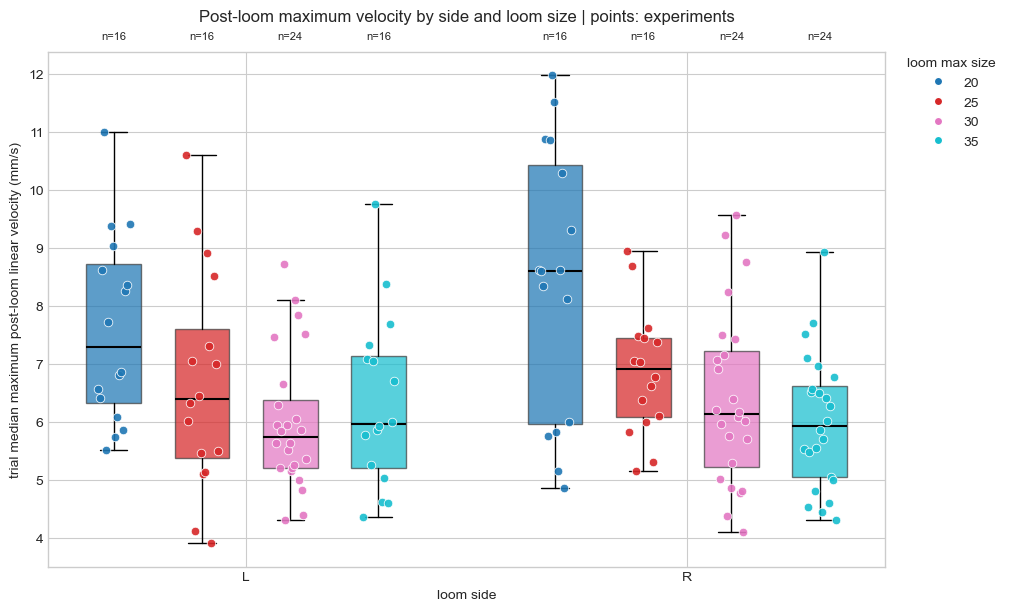

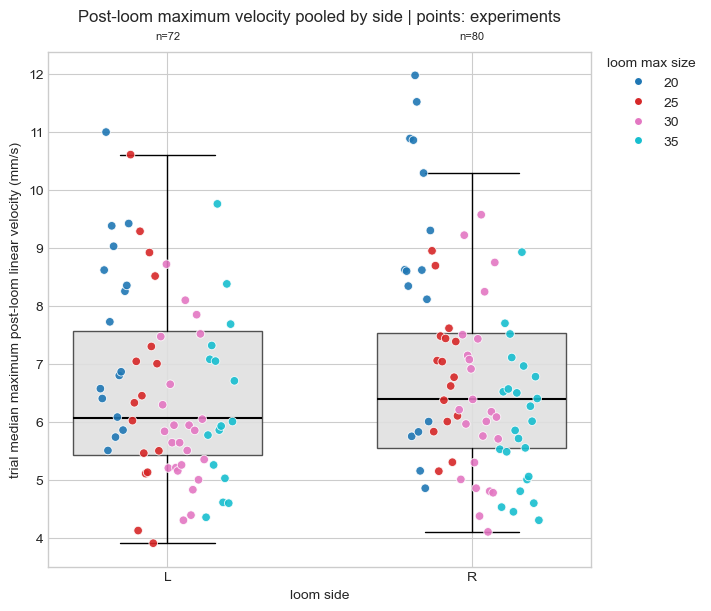

,experiment_index,experiment,trial,condition_trial,block,episode,side,loom_max_size,condition,fixed_loom_onset_frame,time_since_experiment_start_s,time_since_experiment_start_min,trial_median_max_linear_velocity_mm_s,n_fish,txt_path,plot_value,n_experiments
8,0,20260213_01_35Animals_s2_TLSel1F10.1,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,6.573330,34,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.573330,1
48,1,20260303_01_35Animals_s1_TLSel1F10.1,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,6.403124,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.403124,1
88,2,20260305_02_35Animals_s2_TLSel1GC8,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,8.620470,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,8.620470,1
128,3,20260313_01_35Animals_s2_TLSel1F10.1,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,11.002841,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,11.002841,1
168,4,20260330_01_35Animals_s2_TLSel3F8.1,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,5.505679,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,5.505679,1
208,5,20260407_01_35Animals_s2_TLSel1F10.1,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,7.726806,34,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,7.726806,1
248,6,20260507_01_35Animals_s1_TLSel1GC8,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,9.384162,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,9.384162,1
288,7,20260507_02_35Animals_s2_TLSel1GC8,8,1,32,CLfull020L,L,20,20 L,237750,7925.0,132.083333,9.031196,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,9.031196,1
19,0,20260213_01_35Animals_s2_TLSel1F10.1,19,2,43,CLfull020L,L,20,20 L,267450,8915.0,148.583333,5.736970,34,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,5.736970,1
59,1,20260303_01_35Animals_s1_TLSel1F10.1,19,2,43,CLfull020L,L,20,20 L,267450,8915.0,148.583333,6.082763,35,\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsc...,6.082763,1


In [9]:
SIDE_POINT_MODE = 'experiments'  # 'experiments' or 'condition_trial_average'
TRIAL_MAX_VELOCITY_BOXPLOT_SIDES = ['L', 'R']
validate_point_mode(SIDE_POINT_MODE)

side_source = trial_max_velocity.loc[
    trial_max_velocity['loom_max_size'].gt(MAX_LOOM_SIZE_EXCLUDE_THRESHOLD)
    & trial_max_velocity['side'].isin(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)
].copy()
value_column = 'trial_median_max_linear_velocity_mm_s'
if SIDE_POINT_MODE == 'experiments':
    side_points = side_source.copy()
    side_points['plot_value'] = side_points[value_column]
    side_points['n_experiments'] = 1
else:
    side_points = loom.summarize_across_experiments(
        side_source, ['loom_max_size', 'side', 'condition_trial'], [value_column]
    ).rename(columns={f'{value_column}_mean': 'plot_value'})
side_points = side_points.loc[np.isfinite(side_points['plot_value'])].copy()
sizes = sorted(side_points['loom_max_size'].unique())
size_colors = dict(zip(sizes, plt.cm.tab10(np.linspace(0.05, 0.95, len(sizes)))))
box_kwargs = dict(widths=0.62, patch_artist=True, showfliers=False, manage_ticks=False, medianprops={'color': 'black', 'linewidth': 1.5})

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
group_centers = []
group_spacing = len(sizes) + 1
for side_index, side in enumerate(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES):
    positions = []
    for size_index, size in enumerate(sizes):
        subset = side_points.loc[side_points['side'].eq(side) & side_points['loom_max_size'].eq(size)].sort_values('condition_trial')
        position = side_index * group_spacing + size_index
        positions.append(position)
        values = subset['plot_value'].to_numpy(dtype=float)
        ax.boxplot([values], positions=[position], boxprops={'facecolor': size_colors[size], 'edgecolor': '0.25', 'alpha': 0.72}, **box_kwargs)
        ax.scatter(position + deterministic_jitter(len(values), 0.18), values, color=size_colors[size], s=38, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=3)
        ax.text(position, 1.02, f'n={len(values)}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=8)
    group_centers.append(np.mean(positions))
ax.set_xticks(group_centers)
ax.set_xticklabels(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)
ax.set_xlabel('loom side')
ax.set_ylabel('trial median maximum post-loom linear velocity (mm/s)')
ax.set_title(f'Post-loom maximum velocity by side and loom size | points: {SIDE_POINT_MODE}', pad=22)
size_handles = [plt.Line2D([], [], marker='o', linestyle='None', markerfacecolor=size_colors[size], markeredgecolor='white', label=str(int(size))) for size in sizes]
ax.legend(handles=size_handles, title='loom max size', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
positions = {side: index for index, side in enumerate(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)}
ax.boxplot(
    [side_points.loc[side_points['side'].eq(side), 'plot_value'].to_numpy(dtype=float) for side in TRIAL_MAX_VELOCITY_BOXPLOT_SIDES],
    positions=[positions[side] for side in TRIAL_MAX_VELOCITY_BOXPLOT_SIDES],
    boxprops={'facecolor': '0.88', 'edgecolor': '0.25', 'alpha': 0.9},
    **box_kwargs,
)
for side in TRIAL_MAX_VELOCITY_BOXPLOT_SIDES:
    subset = side_points.loc[side_points['side'].eq(side)].sort_values(['loom_max_size', 'condition_trial'])
    values = subset['plot_value'].to_numpy(dtype=float)
    ax.scatter(positions[side] + deterministic_jitter(len(values), 0.22), values, color=[size_colors[size] for size in subset['loom_max_size']], s=38, alpha=0.9, edgecolors='white', linewidths=0.6, zorder=3)
    ax.text(positions[side], 1.02, f'n={len(values)}', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=8)
ax.set_xticks([positions[side] for side in TRIAL_MAX_VELOCITY_BOXPLOT_SIDES])
ax.set_xticklabels(TRIAL_MAX_VELOCITY_BOXPLOT_SIDES)
ax.set_xlabel('loom side')
ax.set_ylabel('trial median maximum post-loom linear velocity (mm/s)')
ax.set_title(f'Post-loom maximum velocity pooled by side | points: {SIDE_POINT_MODE}', pad=22)
ax.legend(handles=size_handles, title='loom max size', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()
display(side_points.sort_values(['side', 'loom_max_size', 'condition_trial']).head(30))